# Semana 6 · Visualización de datos (Python)

**Práctica obligatoria · 1 pomodoro (20 minutos)**

Este documento constituye la guía práctica para la unidad de visualización. Exploraremos las librerías Matplotlib y Seaborn para la generación de gráficos en Python.

El objetivo es aprender no solo a generar el código, sino a entender la gramática detrás de cada gráfico y cómo los elementos preatentivos ayudan a comunicar información de forma instantánea.

> Realizá esta versión o la versión en R. No es necesario completar ambas.

## Resultados esperados

Al finalizar deberías poder:

- conocer los elementos preatentivos;
- generar diagramas y gráficos;
- crear gráficos para conocer el comportamiento de los datos;
- aprender a usar un lenguaje de programación para visualizar datos;

In [20]:
# Importar las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar un estilo visual agradable para los gráficos de Seaborn
sns.set_theme(style="whitegrid")

# Práctica resuelta

## Dataset

Trabajaremos con el dataset 'Tips'. Este dataset de un restaurante contiene datos sobre 244 mesas servidas y la cantidad de propina ofrecida. Se utiliza para detectar cuáles variables están más relacionadas con la cantidad de propina que pagan los comensales.

Aquí se describen en detalle las variables del dataset:

| Variable      | Descripción|
| :------------ | :-|
| `total_bill`    | Precio total de la cuenta |
| `tip`      | Cantidad de propina dada |
| `sex`        | Sexo del comensal que realizó el pago |
| `smoker`         | Indica si la mesa servida se encontraba en la zona para fumadores |
| `day`      | Día de la semana. Thur: jueves; Fri: viernes; Sat: sábado; Sun: domingo|
| `time`        | Momento del día. Lunch: almuerzo; Dinner: cena|
| `size` | Cantidad de comensales que compartieron la mesa |



In [21]:
# Cargar el dataset de tips
df_tips = sns.load_dataset("tips")

## Diagnóstico inicial

Hacemos una breve observación del dataset. Veamos las primeras 5 filas.

In [22]:
# Mostramos las primeras 5 filas para entender la estructura de los datos
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Revisemos cuántas variables y registros posee

In [23]:
df_tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


Ahora veamos un resumen estadístico de todas las variables

In [24]:
df_tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [25]:
display(df_tips['sex'].value_counts())
display(df_tips['smoker'].value_counts())
display(df_tips['day'].value_counts())
display(df_tips['time'].value_counts())

,count
sex,
Male,157
Female,87


,count
smoker,
No,151
Yes,93


,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


,count
time,
Dinner,176
Lunch,68


## Visualización de datos

### GRÁFICA 1

#### Tipo de Gráfico

Histograma con Curva de Densidad (KDE - Kernel Density Estimation)

#### Características Principales

- Muestra la frecuencia de observaciones en intervalos (bins) de la cuenta total
- Incluye una curva de densidad superpuesta para visualizar la distribución suave
- 20 intervalos (bins) para granularidad en los datos
- Eje X: Cuenta Total ($)
- Eje Y: Frecuencia (cantidad de mesas)

#### Elementos Preatentivos Utilizados

- **Posición (eje X)**: La ubicación de las barras en el eje horizontal indica el monto atribuido
- **Longitud**: Tamaño de las barras representa directamente la frecuencia

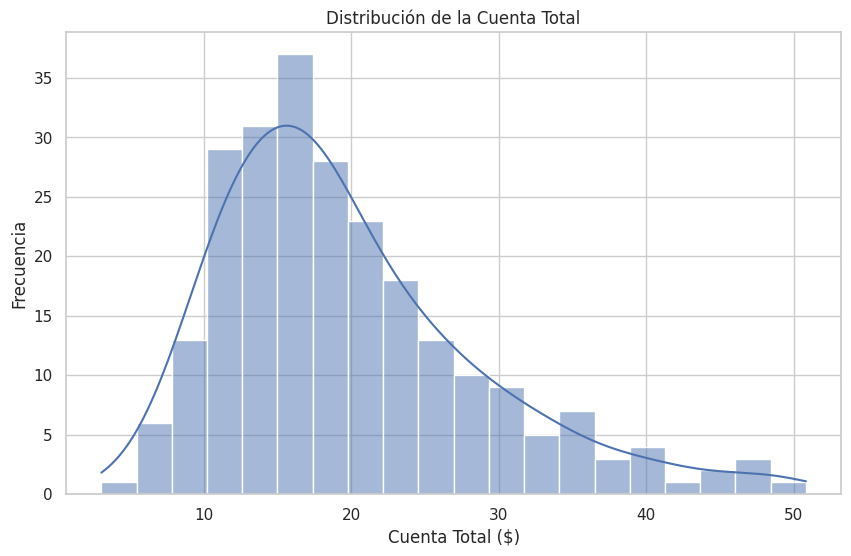

In [26]:
# Crear un histograma de la columna 'total_bill'
plt.figure(figsize=(10, 6))
sns.histplot(data=df_tips, x="total_bill", kde=True, bins=20)
plt.title('Distribución de la Cuenta Total')
plt.xlabel('Cuenta Total ($)')
plt.ylabel('Frecuencia')
plt.show()

**Conclusión**

A partir de este histograma, podemos observar que el valor central se encuentra entre 15 y 20, tiene una asimetría hacia la derecha y tiene valores altos como aquellos cercanos a 50, aunque pueden no ser considerados atípicos por la suavidad con la que se llega a ese punto.


### GRÁFICA 2

#### Tipo de Gráfico
Gráfico de Conteo (Countplot) por Día de la Semana

#### Características Principales
- Muestra el número de mesas (registros) por cada día de la semana.
- Barras verticales para cada categoría (día).
- Eje X: Día de la Semana.
- Eje Y: Cantidad de Mesas.
#### Elementos Preatentivos Utilizados
- **Posición (eje X)**: Las barras se ubican de izquierda a derecha ordenadas por día de la semana.
- **Longitud/Altura**: Variable principal que representa la frecuencia (cantidad de mesas).

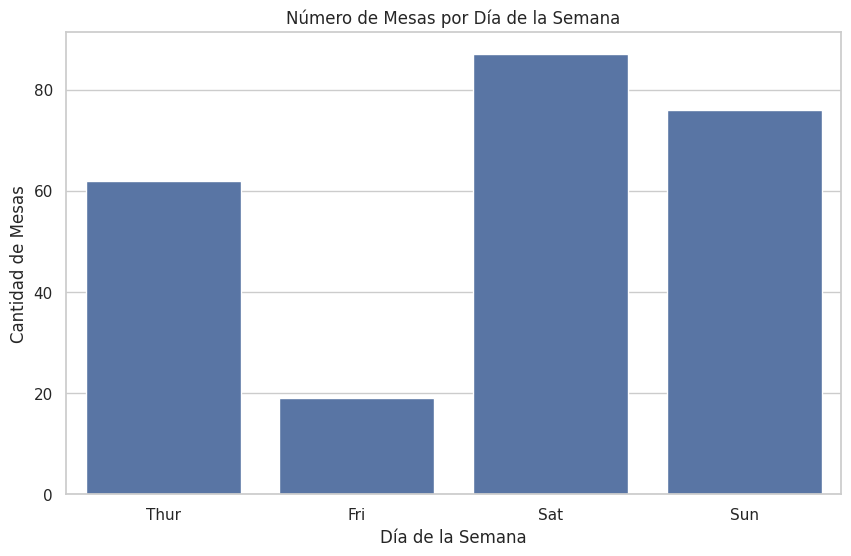

In [27]:
# Crear un gráfico de conteo para la variable 'day' (día de la semana)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_tips, x="day", order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title('Número de Mesas por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Cantidad de Mesas')
plt.show()

**Conclusión**

Este gráfico muestra la frecuencia de mesas atendidas en cada día de la semana. Se pueden observar que los días más concurridos son los sábados, aunque muy comparable con los jueves y domingos. El viernes es el día menos concurrido; muy poco frecuente respecto a los otros días.


### GRÁFICA 3

#### Tipo de Gráfico
Gráfico de Dispersión Multidimensional (Scatter Plot)

#### Características Principales
- Analiza la relación entre dos variables numéricas: `total_bill` (cuenta total) y `tip` (propina)
- Incluye dos variables categóricas codificadas visualmente:
  - **Hue (Color)**: `sex` (sexo del que pagó)
  - **Style (Marca)**: `smoker` (si la mesa estaba en zona de fumadores)
- Permite visualizar patrones multidimensionales en un espacio 2D

#### Elementos Preatentivos Utilizados
- **Posición (X, Y)**: Ubicación de puntos muestra relación entre cuenta total y propina
- **Color (Hue)**: Diferencia entre géneros (masculino/femenino)
- **Forma (Marker)**: Diferencia entre fumadores y no fumadores
- *Nota:* Se podrían haber agregado otras variaciones como el tamaño o el contraste cromático para agregar más variables a la gráfica, aunque esto puede volver a la gráfica menos comprensible visualmente.
- **Contraste cromático**: Colores diferenciadores para el género

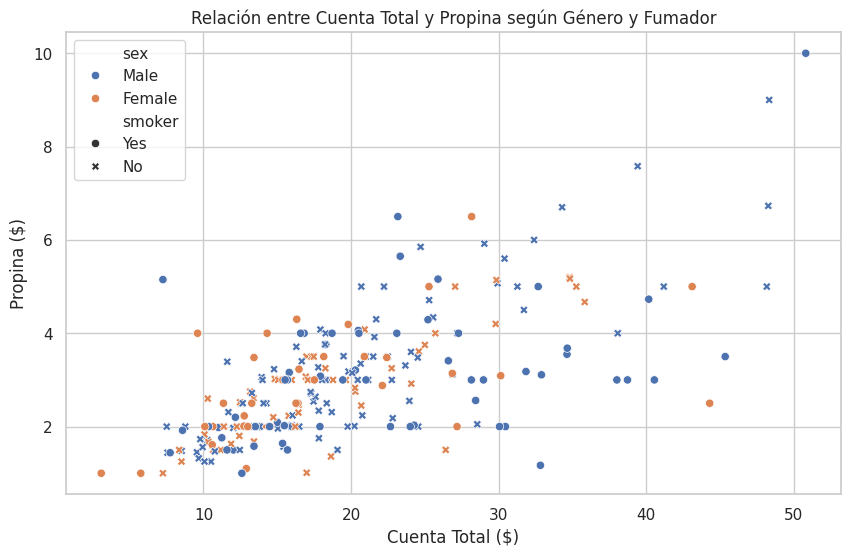

In [28]:
# Gráfico de dispersión entre 'total_bill' (cuenta total) y 'tip' (propina)
plt.figure(figsize=(10, 6))
# Podemos agregar una tercera y cuarta variable categórica usando los parámetros 'hue' y 'style'
sns.scatterplot(data=df_tips, x="total_bill", y="tip", hue="sex", style="smoker")
plt.title('Relación entre Cuenta Total y Propina según Género y Fumador')
plt.xlabel('Cuenta Total ($)')
plt.ylabel('Propina ($)')
plt.show()

**Conclusión**

De esta gráfica podemos sacar varias ideas.
* Existe una tendencia general donde a mayor cuenta total, mayor propina.
* No se observan diferencias claras cuando las propinas las da un hombre versus si las paga una mujer.
* No hay diferencias claras en la propinas dadas entre los fumadores y los no fumadores.


### GRÁFICA 4

#### Tipo de Gráfico
Diagrama de Caja (Box Plot) con Estratificación

#### Características Principales
- Muestra la distribución de las propinas (`tip`) por día de la semana (`day`)
- Dividido por el momento del día (`time`) para estratificación adicional. Es decir, para cada día hay 2 cajas: una para 'Lunch' y otra para 'Dinner'.
#### Elementos Preatentivos Utilizados
- **Posición (eje x)**: Separado en el eje x por días de la semana.
- **Color (Hue)**: Diferencia entre 'Lunch' y 'Dinner'.
- **Longitud y Forma**: Tamaño de la caja representa el rango intercuartílico de las propinas.

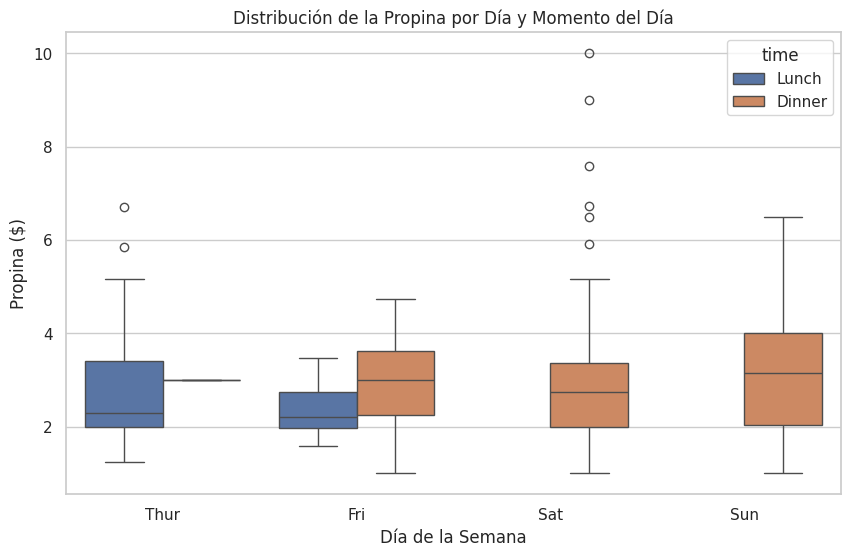

In [29]:
# Box plot para ver la distribución de la propina por día y momento del día
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_tips, x="day", y="tip", hue="time", order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title('Distribución de la Propina por Día y Momento del Día')
plt.xlabel('Día de la Semana')
plt.ylabel('Propina ($)')
plt.show()

**Conclusión**

Este box plot nos permite analizar la distribución de las propinas de acuerdo al día de la semana y el momento del día (almuerzo o cena):
- **Variabilidad**: Los días con mayor variabilidad son los sábados y domingos.
- **Momento del Día**: Los jueves casi siempre se sirven almuerzos y en los sábados y domingos solamente cenas. Los viernes se sirvieron tanto almuerzos como cenas.
- **Outliers**: Los días sábados presentan una cantidad muy alta de valores atípicos, presentando valores máximos respecto a todo el conjunto de propinas.
- **Tendencias en propinas**: Se puede deducir mediante la comparación de las medianas que en las cenas se suelen recibir más propinas en comparación con los almuerzos. El caso del día viernes queda bastante clara esta tendencia. Por otro lado, el día no parece afectar en la cantidad de propina dada.


### GRÁFICA 5

#### Tipo de Gráfico
Gráfico de Barras Categórico (Bar Plot) del promedio de la cuenta total

#### Características Principales
- Muestra el valor promedio de la `total_bill` (cuenta total) por cada `size` (cantidad de comensales en la mesa)
- Utiliza `smoker` para subdividir las barras, permitiendo comparar promedios por fumador y no fumador.
- **Barras de error** para visualizar el intervalo de confianza para la media poblacional.
- Eje X: Cantidad de comensales en la mesa
- Color: Fumador o no fumador
- Eje Y: Cuenta Total Promedio ($)

#### Elementos Preatentivos Utilizados
- **Posición (eje X)**: Barras ubicadas de izquierda a derecha por cantidad de comensales.
- **Longitud/Altura**: Proporcional a la cuenta total promedio.
- **Color (Hue)**: Diferencia entre los fumadores y no fumadores.

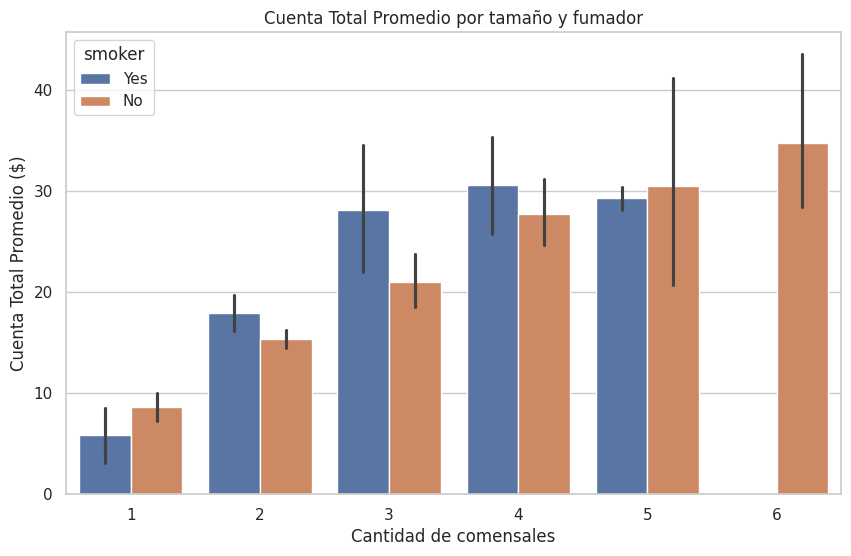

In [30]:
# Gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=df_tips, x="size", y="total_bill", hue="smoker")
plt.title('Cuenta Total Promedio por tamaño y fumador')
plt.xlabel('Cantidad de comensales')
plt.ylabel('Cuenta Total Promedio ($)')
plt.show()

**Conclusión**

Este gráfico de barras nos permite observar la cuenta total promedio:
- Los fumadores suelen gastar más en la comida que los no fumadores. La única excepción son los casos donde hay una sola persona en la mesa.
- El monto total de la cuenta aumenta a medida que más personas hay en la mesa.
- En las mesas con 3 y 4 personas, los fumadores presentan un intervalo de confianza más amplio en el gasto total. Por otro lado, en las mesas con 5 y 6 personas, los no fumadores presentan un intervalo de confianza amplio.


### GRÁFICA 6

#### Tipo de Gráfico
Mapa de Calor (Heatmap) de Propina Promedio por Día-Momento y Tamaño de Mesa

#### Características Principales
- Visualiza el valor promedio de la `tip` (propina) en una cuadrícula.
- El eje horizontal (columnas) representa el `size` (cantidad de comensales).
- El eje vertical (filas) representa la combinatoria de `day` (día de la semana) y `time` (momento del día: Lunch/Dinner).
- Cada celda muestra la propina promedio para esa combinación específica de día, momento del día y tamaño de mesa.

#### Elementos Preatentivos Utilizados
- **Color (Hue)**: Utiliza una escala de color para representar el valor de la propina promedio, donde colores más intensos (generalmente amarillos en 'viridis') indican propinas más altas y colores más suaves (morados/azules) propinas más bajas.
- **Saturación**: La intensidad del color ayuda a identificar rápidamente las combinaciones con mayor o menor propina.
- **Posición**: La ubicación de cada celda en la cuadrícula corresponde a una combinación específica de día-momento y tamaño de mesa.
- **Anotaciones numéricas**: Los valores exactos de la propina promedio se muestran dentro de cada celda para una lectura precisa.

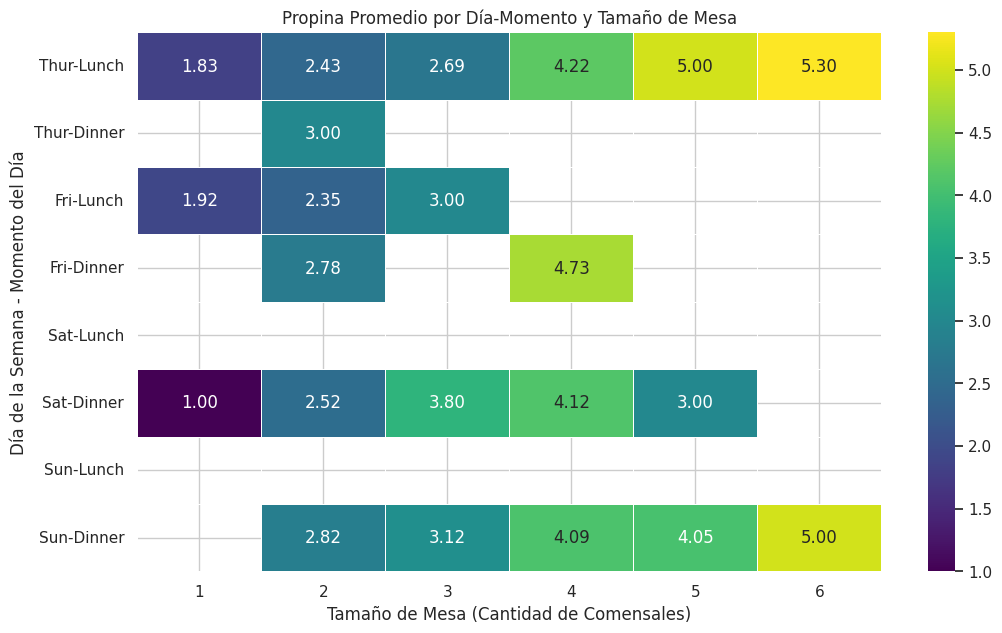

In [31]:
# 1. Calcular la propina promedio por la combinatoria de día-momento y por tamaño de mesa
tip_avg_by_day_time_size = df_tips.groupby(['day', 'time', 'size'], observed=False)['tip'].mean().unstack(level='size')

# El orden de los días y momentos (índices de fila) y los tamaños (columnas) ya está establecido correctamente por el groupby y unstack.

# 2. Crear el mapa de calor
plt.figure(figsize=(12, 7))
sns.heatmap(tip_avg_by_day_time_size, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Propina Promedio por Día-Momento y Tamaño de Mesa')
plt.xlabel('Tamaño de Mesa (Cantidad de Comensales)')
plt.ylabel('Día de la Semana - Momento del Día')
plt.show()

**Conclusión**

Este mapa de calor nos permite un análisis detallado de la propina promedio, considerando la combinatoria de día-momento y el tamaño de la mesa:

- **Propinas por Tamaño de Mesa**: Generalmente, las propinas promedio aumentan a medida que el `size` (cantidad de comensales) es mayor, aunque hay excepciones y valores `NaN` donde no hubo datos.
- **Combinación Día-Momento más Lucrativa**: Las propinas promedio más altas se observan en las `cenas de los domingos` (Sun-Dinner) y los `almuerzos de los jueves` (Thur-Lunch), especialmente para mesas grandes (size 4, 5 y 6).
- **Distribución de Datos**: Es importante notar la presencia de celdas vacías (`NaN`), que indican que no hubo registros para esa combinación específica de día, momento y tamaño de mesa (ej. no hay almuerzos los sábados o domingos, o mesas de 6 personas en la cena de los jueves).
- **Variaciones Significativas**: Podemos ver que, por ejemplo, una mesa de 4 comensales en el almuerzo del jueves (Thur-Lunch) deja una propina promedio de 4.22, mientras que la cena del sábado (Sat-Dinner) con 4 comensales es de 4.12. Esto sugiere que no solo el tamaño de la mesa, sino también el día y el momento, son factores interconectados que influyen en las propinas.

### GRÁFICA 7

#### Tipo de Gráfico
Matriz de Gráficos de Dispersión y Densidad (Pairplot)

#### Características Principales
- Visualiza **relaciones entre todos los pares de variables numéricas** simultáneamente
- Diagonal principal: Gráficos de densidad KDE para cada variable
- Triángulo inferior/superior: Gráficos de dispersión para relaciones bivariadas
- Coloreado por **sexo** (hombres vs mujeres)
#### Elementos Preatentivos Utilizados
- **Color (Hue)**: Diferencia entre hombres (azul) y mujeres (naranja) en todos los gráficos
- **Posición (X, Y)**: Ubicación de puntos en cada scatter plot


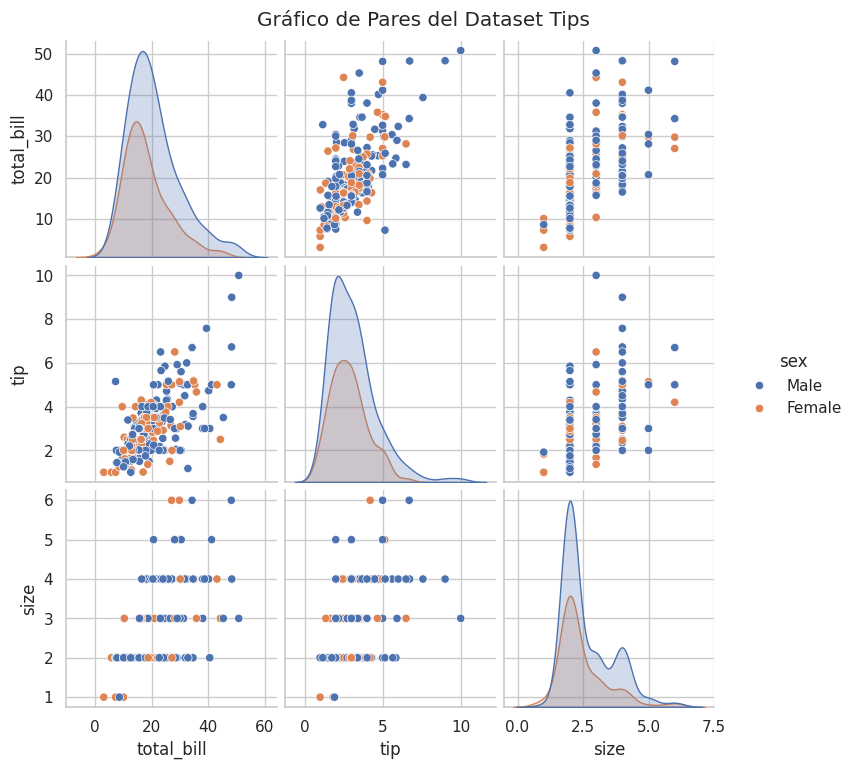

In [32]:
# Crear un pairplot, coloreando por la variable 'sex'
# ¡Cuidado! Puede ser lento si el dataset es muy grande.
sns.pairplot(df_tips, hue="sex", diag_kind="kde")
plt.suptitle('Gráfico de Pares del Dataset Tips', y=1.02) # Título general
plt.show()

## CONCLUSIONES GENERALES DEL ANÁLISIS

El análisis exhaustivo del dataset de propinas revela patrones claros en el comportamiento de los clientes y la estructura de las propinas en el restaurante. Hemos observado que la `cuenta total` tiene una distribución asimétrica y una correlación directa con la `propina`, lo que sugiere que a mayor gasto, mayor propina.

La actividad del restaurante se concentra significativamente los fines de semana, siendo los sábados los días más concurridos y los viernes los menos. Esta concentración de mesas se traduce en patrones de propina diferenciados: las `cenas de fin de semana` (especialmente sábados y domingos) son consistentemente los momentos donde se reciben las propinas promedio más altas. Esta tendencia es más marcada en comparación con los almuerzos o los días de semana, donde las propinas tienden a ser menores. Esto destaca la importancia de la `franja horaria` y el `día de la semana` como factores clave que influyen en las propinas.

Por otro lado, factores como el `sexo` del pagador y el `hábito de fumar` parecen tener una influencia menos directa o significativa en las propinas o la cuenta total promedio, al menos de manera aislada. Sin embargo, el `tamaño de la mesa` sí muestra un impacto claro en la `cuenta total promedio`, que aumenta proporcionalmente con el número de comensales. Curiosamente, los fumadores tienden a gastar más que los no fumadores en mesas grandes, aunque con mayor variabilidad.

En resumen, los factores más influyentes en las propinas son el monto de la cuenta total, el día de la semana, y el momento del día (almuerzo vs. cena). Estos hallazgos son cruciales para la gestión del restaurante, permitiendo optimizar la asignación de personal o las estrategias de servicio en función de los momentos de mayor afluencia y potencial de propinas.

# Práctica autónoma

## Dataset: Medical Cost Personal

Trabajaremos con el dataset 'Medical Cost Personal'. Contiene datos de 1.338 asegurados de una compañía de seguros de salud de Estados Unidos y el costo anual que cada uno le generó a la aseguradora. Nuestro objetivo es usar la visualización de datos para responder algunas preguntas.

Aquí se describen en detalle las variables del dataset:

| Variable | Descripción |
| :--- | :--- |
| `age` | Edad del asegurado, entre 18 y 64 años |
| `sex` | Sexo del asegurado (`female`, `male`) |
| `bmi` | Índice de masa corporal, en kg/m² |
| `children` | Cantidad de hijos a cargo cubiertos por el seguro, de 0 a 5 |
| `smoker` | Indica si el asegurado es fumador (`yes`, `no`) |
| `region` | Región de residencia (`northeast`, `northwest`, `southeast`, `southwest`) |
| `charges` | Costo anual facturado a la aseguradora, en dólares |

**Importante**: El conjunto ya puede utilizarse sin una etapa previa de limpieza.

Con la siguiente celda podrás obtener el dataset completo. Si llega a generar errores o problemas, podés descargar el dataset que está subido en el aula virtual, subirlo a la carpeta "Archivos" de colab y ejecutar el siguiente código:

```
df_seguro = pd.read_csv('/content/insurance.csv')
```

In [33]:
# Cargar el dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df_seguro = pd.read_csv(url)

In [34]:
# Primeras 5 filas del dataset
df_seguro.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [35]:
# Información general del dataset
df_seguro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [36]:
# Resumen estadístico del dataset
df_seguro.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Consignas

Respondé cada una de las siguientes preguntas apoyándote en las gráficas que consideres necesarias. **Salvo cuando se indique lo contrario, la elección del tipo de gráfico queda a tu criterio: decidir cuál comunica mejor cada respuesta es parte del ejercicio.**

No te olvides de ponerle título y etiquetas a tus gráficos para mejorar su comprensión.

1. ¿Existe alguna relación entre la edad (*age*) y el costo anual (*charges*)? Describí la forma que toma esa relación. ¿Alcanzaría una única tendencia para resumirla?

2. ¿Existe alguna tendencia o relación entre las variables *bmi*, *age* y *sex*?

3. Creá una matriz de gráficos (*pairplot*) que muestre todas las relaciones entre las variables numéricas del dataset, distinguiendo los puntos por color según la variable *smoker*. Indicá qué par de variables separa con mayor claridad a los dos grupos.

4. ¿Cuántos asegurados hay en cada región?

5. ¿Existe una relación entre la cantidad de hijos a cargo (*children*) y el costo anual? ¿Ves algún valor atípico (*outlier*) en los resultados?

6. Compará *charges* entre hombres y mujeres, separando fumadores de no fumadores. Escribí una conclusión **para cada una de las dos variables**: ¿el sexo influye en el costo?, ¿influye ser fumador? Justificá ambas respuestas por separado.

7. Realizá un gráfico a elección y escribí una conclusión sobre lo observado.

8. **Conclusión final:** desarrollá brevemente en un párrafo el comportamiento de los datos que componen el conjunto estudiado. Indicá cuáles son las variables que más influyen sobre el costo anual y cuáles resultaron poco relevantes.


### **IMPORTANTE**

En cada ítem debés responder indicando:
* Tipo de Gráfico
* Características Principales
* Elementos Preatentivos Utilizados
* Conclusión del gráfico realizado indicando qué se observó en ella y qué relevancia tiene ese hallazgo.